In [1]:
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset

In [2]:
# 1. Load the TRANSP NetCDF file
file_path = "162940C01.CDF"
nc = Dataset(file_path, "r")

In [37]:
# Print all variable names that contain 'P' or look like heat transport
for var in nc.variables:
    if var.startswith("X") and len(var) <= 20:
        print(f"{var}: {nc.variables[var].long_name if 'long_name' in nc.variables[var].ncattrs() else ''}")

X: x"r/a" ctr                                                      
XB: x"r/a" bdy                                                      
XIRSYM: FLUX LABEL (DATA MAPPING)                                       
XETE0: CHI:E(ETA(E)) GUZDAR                                            
XETAE: CHI:E(ETA(E)) ACTIVE                                            
XKFAC: CHI(I) MULTIPLIER                                               
XETI0: CHI(ETA(I)) RAW                                                 
XKINC: NEOCLASSICAL CHI(I)                                             
XKEPALEO: PALEOCLASSICAL CHI(E)                                           
XKAPIGKF: IFS-PPPL GYROFLUID MODEL CHI(I)                                 
XKAPEGKF: IFS-PPPL GYROFLUID MODEL CHI(E)                                 
XKIGLF23: GLF23 MODEL CHI(I)                                              
XKEGLF23: GLF23 MODEL CHI(E)                                              
XKINEO: NEO MODEL CHI(I)                               

In [28]:
# Search the descriptions for the word 'volume'
for var_name in nc.variables:
    var = nc.variables[var_name]
    
    if 'long_name' in var.ncattrs():
        desc_str = str(var.long_name).lower()
        
        if "radial" in desc_str:
            # Safely grab units if they exist
            units = var.units if 'units' in var.ncattrs() else "No units"
            print(f"{var_name:<15} | {units:<25} | {var.long_name}")

IBRORB_D        | AMPS                             | D BEAM ION RADIAL CUR (ORBIT)                                   
CURBRORB        | AMPS                             | FAST ION RADIAL CURRENT (ORBIT)                                 
VNDNC_E         | CM/SEC                           | NCLASS e- radial particle convection velocity                   
ERTOT           | V/CM                             | NC radial E Field                                               
ERPRESS         | V/CM                             | NC radial E field, Pressure term                                
ERVPOL          | V/CM                             | NC radial E field, Vpol term                                    
ERVTOR          | V/CM                             | NC radial E field, Vtor term                                    
VNDNC_TOK       | CM/SEC                           | Nclass avg radial particle convection velocity forTOK           
VNDNC_D         | CM/SEC                           | Ncl

In [16]:
print(f"{'Variable Name':<15} | {'Shape':<15} | {'Description'}")
print("-" * 75)

for var_name in nc.variables:
    var = nc.variables[var_name]
    if len(var.shape) == 2:  # Only look at 2D profiles
        desc = var.long_name.lower() if 'long_name' in var.ncattrs() else ""
        if "vol" in var_name.lower() or "volume" in desc:
            print(f"{var_name:<15} | {str(var.shape):<15} | {var.long_name if 'long_name' in var.ncattrs() else ''}")

Variable Name   | Shape           | Description
---------------------------------------------------------------------------
BMVOL           | (423, 220)      | 2d MC grid zone volumes                                         
DVOL            | (423, 50)       | ZONE VOLUME                                                     
S0VOL           | (423, 50)       | TOTAL NEUTRAL VOL E-SCE                                         


In [16]:
# Check what variables actually exist and read their attributes
target_vars = ["PCOND", "PCONV", "PC_E", "PV_E", "PLFE", "PLFI"]

for v in target_vars:
    if v in nc.variables:
        units = nc.variables[v].units if 'units' in nc.variables[v].ncattrs() else "Unknown"
        long_name = nc.variables[v].long_name if 'long_name' in nc.variables[v].ncattrs() else ""
        print(f"Variable: {v:7} | Units: {units:12} | Description: {long_name}")


Variable: PCOND   | Units: WATTS/CM3                        | Description: ION CONDUCTION LOSS                                             
Variable: PCONV   | Units: WATTS/CM3                        | Description: ION CONVECTION LOSS                                             


In [17]:
print(f"{'Variable Name':<15} | {'Units':<20} | {'Description'}")
print("-" * 80)

# Loop through all variables to find power quantities
for var_name in nc.variables:
    var = nc.variables[var_name]
    
    # Check if the variable has a 'units' attribute
    if 'units' in var.ncattrs():
        units_str = str(var.units).upper()
        
        # Look for WATTS, WATT, or MW in the units string
        if "WATT" in units_str or "MW" in units_str:
            # Safely grab the long_name/description if it exists
            desc = var.long_name if 'long_name' in var.ncattrs() else "No description"
            
            print(f"{var_name:<15} | {var.units:<20} | {desc}")

Variable Name   | Units                | Description
--------------------------------------------------------------------------------
POH             | WATTS/CM3                        | OHMIC HEATING POWER                                             
UDEXB           | WATTS/CM3                        | E CROSS B POWER                                                 
UBTDT           | WATTS/CM3                        | D/DT(FIELD ENERGY)                                              
UBPDT           | WATTS/CM3                        | D/DT(POLOIDAL FIELD ENERGY)                                     
UBCMP           | WATTS/CM3                        | B(POL) COMPRESSION                                              
UMGBA           | WATTS/CM3                        | MAGDIF ENERGY BALANCE                                           
QFLNC_TOK       | WATTS/CM3                        | div(NC heat flux) TOK imp                                       
QFLNCC_TOK      | WATTS/CM3             

In [3]:
# 2. Extract coordinates (Time and Radial Grid)
# TIME is usually 1D. TIME_V denotes the time axis for profiles.
time = nc.variables["TIME"][:]  # Time array in seconds
rhotor = nc.variables["X"][:] #rhotor ?
dvol = nc.variables["DVOL"][:]  # Volume profile in cm^3

# 4. Pick a specific time slice to plot
# Let's find the index closest to a target time (e.g., 2.5 seconds)
#target_time = 2.5  
#time_idx = np.abs(time - target_time).argmin()
time_idx = -1 
actual_time = time[time_idx]

# Slice data for this specific time
rhotor_slice = rhotor[time_idx, :] if rhotor.ndim == 2 else rhotor
dvol_slice = dvol[time_idx,:] 

# 3. Extract Transport Powers (Conduction + Convection)
# Units in TRANSP NetCDF are typically Watts. We will convert to MW (/1e6).
# Electron channel
p_cond_e = nc.variables["PCNDE"][time_idx,:]  # Electron conduction power
p_conv_e = nc.variables["PCNVE"][time_idx,:]  # Electron convection power
p_total_e = (p_cond_e + p_conv_e)

# Ion channel
p_cond_i = nc.variables["PCOND"][time_idx,:]  # Ion conduction power
p_conv_i = nc.variables["PCONV"][time_idx,:]  # Ion convection power
p_total_i = (p_cond_i + p_conv_i)

# Perform the Volume Integration to get Watts, then divide by 1e6 for MW
p_total_e_mw = np.cumsum(p_total_e*dvol_slice) / 1e6
p_total_i_mw = np.cumsum(p_total_i*dvol_slice) / 1e6


In [40]:
nc.variables["XILMP"]

<class 'netCDF4.Variable'>
float32 XILMP(TIME3, RMAJM)
    units:                                 
    long_name: TOROIDAL FLUX LABEL                                             
unlimited dimensions: 
current shape = (423, 101)
filling on, default _FillValue of 9.969209968386869e+36 used

In [ ]:
print("Shape of PVOLF:", nc.variables[""].shape)
print("Dimensions of PVOLF:", nc.variables["PVOL"].dimensions)

In [14]:
print("Shape of PVOLF:", nc.variables["PVOL"].shape)
print("Dimensions of PVOLF:", nc.variables["PVOL"].dimensions)

Shape of PVOLF: (423,)
Dimensions of PVOLF: ('TIME',)


In [15]:
print("Shape of PCOND:", nc.variables["PCOND"].shape)
print("Dimensions of PCOND:", nc.variables["PCOND"].dimensions)

Shape of PCOND: (423, 50)
Dimensions of PCOND: ('TIME3', 'X')


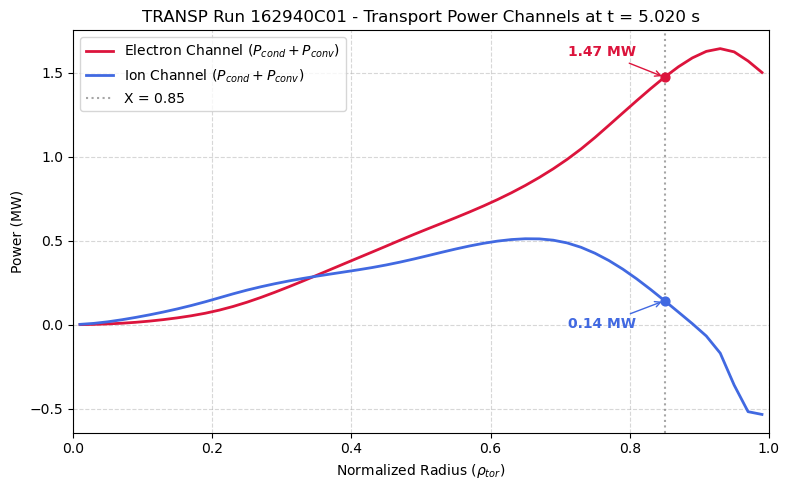

In [5]:
# 5. Plot the Results
plt.figure(figsize=(8, 5))
plt.plot(rhotor_slice, p_total_e_mw, label="Electron Channel ($P_{cond} + P_{conv}$)", color="crimson", lw=2)
plt.plot(rhotor_slice, p_total_i_mw, label="Ion Channel ($P_{cond} + P_{conv}$)", color="royalblue", lw=2)

# Add explicit markers at x = 0.85
# 8. Find the values at the coordinate index closest to 0.85
target_x = 0.85
idx_085 = np.abs(rhotor_slice - target_x).argmin()
actual_x = rhotor_slice[idx_085]
val_e = p_total_e_mw[idx_085]
val_i = p_total_i_mw[idx_085]

plt.scatter([actual_x], [val_e], color="crimson", s=40, zorder=5)
plt.scatter([actual_x], [val_i], color="royalblue", s=40, zorder=5)

# Annotate values with slight offsets to ensure they remain clear and legible
plt.annotate(f"{val_e:.2f} MW", (actual_x, val_e), textcoords="offset points", xytext=(-45, 15),
             ha='center', color="crimson", weight='bold',
             arrowprops=dict(arrowstyle="->", color="crimson", lw=1))

plt.annotate(f"{val_i:.2f} MW", (actual_x, val_i), textcoords="offset points", xytext=(-45, -20),
             ha='center', color="royalblue", weight='bold',
             arrowprops=dict(arrowstyle="->", color="royalblue", lw=1))

# Draw a vertical reference line at the target coordinate
plt.axvline(x=actual_x, color="gray", linestyle=":", alpha=0.7, label=f"X = {actual_x:.2f}")

plt.title(f"TRANSP Run 162940C01 - Transport Power Channels at t = {actual_time:.3f} s")
plt.xlabel(r"Normalized Radius ($\rho_{tor}$)")
plt.ylabel("Power (MW)")
plt.xlim(0, 1)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()

# Display the plot
plt.tight_layout()
plt.show()